In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


In [124]:
DATA_PATH = "../data/processed/nykaa_campaign_cleaned.csv"

df = pd.read_csv(DATA_PATH)

print(f"Shape of dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape of dataset: 55555 rows x 16 columns


,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,2025-04-29
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,2025-04-06
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,2025-01-14
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,2025-06-04
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,2024-12-29


In [125]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

Duplicate rows: 0


In [128]:
required_columns = [
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "Acquisition_Cost",
    "ROI",
    "Engagement_Score",
    "Campaign_Type",
    "Channel_Used",
    "Customer_Segment",
    "Target_Audience",
    "Date"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are present.")

All required columns are present.


## Numerical Summary

In [131]:
core_metrics = [
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "Acquisition_Cost",
    "ROI",
    "Engagement_Score"
]

print("Core metrics found in dataset:", core_metrics)

df[core_metrics].describe().T

Core metrics found in dataset: ['Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI', 'Engagement_Score']


,count,mean,std,min,25%,50%,75%,max
Impressions,55555.0,55087.885357,25930.001514,10001.00,32680.000,55182.00,77514.500,100000.00
Clicks,55555.0,4688.070507,3178.686285,202.00,2110.000,3907.00,6688.000,14868.00
Leads,55555.0,1877.271119,1435.636117,56.00,779.000,1481.00,2605.000,8876.00
Conversions,55555.0,1032.866925,862.496788,19.00,400.000,779.00,1414.000,6686.00
Revenue,55555.0,515819.715273,490012.112118,6183.00,177706.000,360436.00,687422.500,4579910.00
Acquisition_Cost,55555.0,377.347068,541.084524,9.08,105.435,207.51,428.580,15473.16
ROI,55555.0,2.713807,4.493380,-0.97,0.040,1.24,3.630,74.42
Engagement_Score,55555.0,13.784169,6.353125,2.60,8.360,13.60,18.855,30.91


In [133]:
# Skewness of core numerical metrics -> helps decide which need
# outlier attention / log-scale plotting later
skew_table = df[core_metrics].skew().sort_values(ascending=False)
print("Skewness of core metrics (sorted):")
skew_table


Skewness of core metrics (sorted):


Acquisition_Cost    5.395360
ROI                 3.445182
Revenue             2.042130
Conversions         1.584379
Leads               1.237999
Clicks              0.822055
Engagement_Score    0.160697
Impressions        -0.005832
dtype: float64

#
# -0.5 to +0.5 -> roughly symmetric
# +0.5 to +1 -> moderately right-skewed
# > +1 -> strongly right-skewed
# -1 to -0.5 -> moderately left-skewed
# < -1 -> strongly left-skewed


The skewness analysis shows that most numerical marketing metrics are positively skewed, meaning that while most campaigns have relatively moderate values, a smaller number of campaigns have much higher values. Acquisition Cost and ROI show the highest skewness. Revenue, Conversions, Leads and Clicks are also right-skewed. In contrast, Engagement Score and Impressions are approximately symmetrically distributed.

## Univariate EDA

* **Impressions:** Values are fairly evenly distributed across the range.
* **Clicks:** Higher click values occur in fewer campaigns.
* **Leads:** Higher lead values occur in fewer campaigns.
* **Conversions:** Higher conversion values occur in fewer campaigns.
* **Revenue:** Higher revenue values occur in fewer campaigns.
* **Acquisition Cost:** Most campaigns have low costs, with fewer campaigns having very high costs.
* **ROI:** Most campaigns have low ROI, while high ROI values occur in fewer campaigns.
* **Engagement Score:** Values are relatively evenly distributed, with fewer observations at the highest scores.


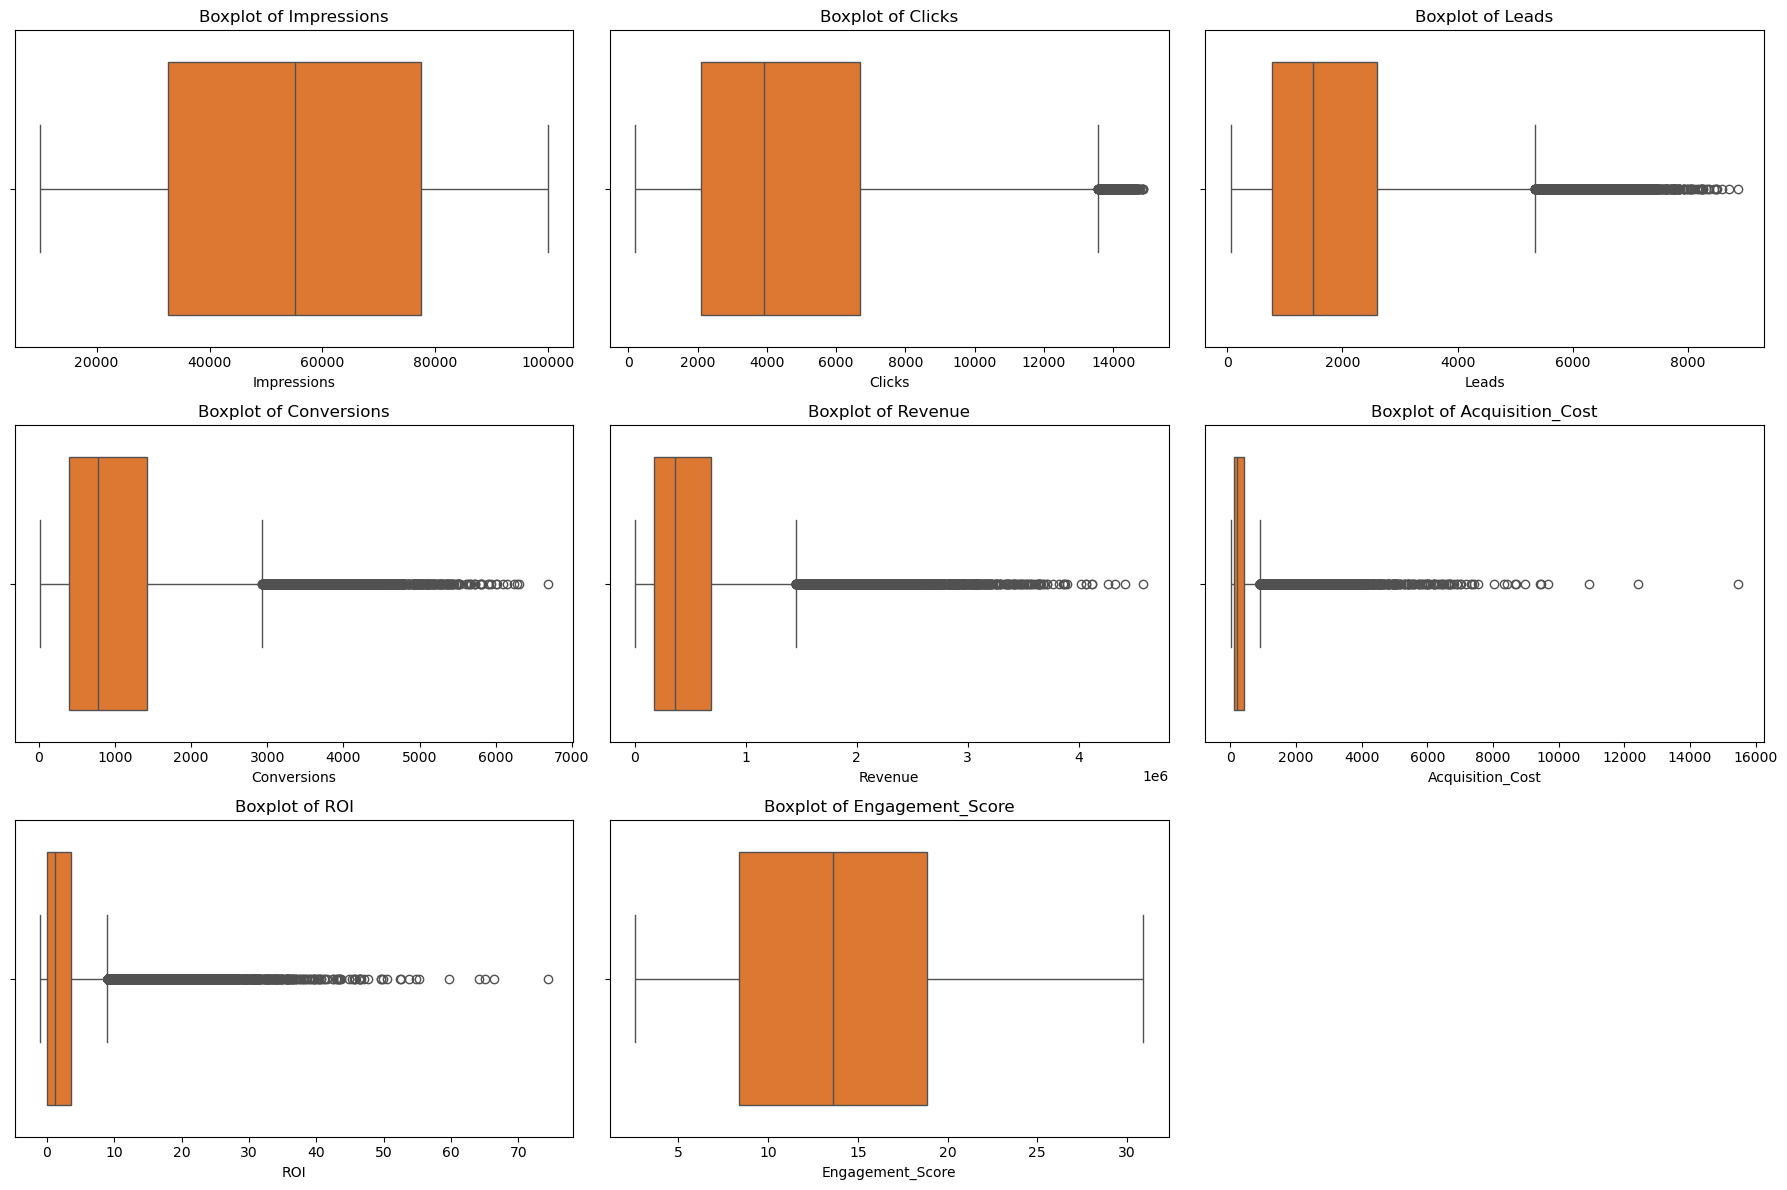

In [145]:
# Boxplots to visualise spread and outliers

n = len(core_metrics)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(core_metrics):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color='#f97316'
    )
    axes[i].set_title(f'Boxplot of {col}')

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Impressions: The values are widely spread, with no major outliers visible.
* Clicks: Most values are concentrated in the lower-to-middle range, with some high-value outliers.
* Leads: Most campaigns have lower-to-moderate leads, with many high-value outliers.
* Conversions: Most values are concentrated toward the lower range, with many high conversion outliers.
* Revenue: Most campaigns have relatively lower revenue, with many high-revenue outliers.
* Acquisition Cost: Most campaigns have low acquisition costs, with many extremely high-cost outliers.
* ROI: Most campaigns have relatively low ROI, with many high-ROI outliers extending far to the right.
* E ngagement Score: Values are relatively spread out with no prominent outliers.

In [147]:
# IQR-based outlier count per core metric (for reporting only —
# no rows are removed/modified in this EDA notebook)
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = pd.DataFrame({
    'column': core_metrics,
    'outlier_count': [iqr_outlier_count(df[c]) for c in core_metrics],
    'outlier_pct': [round(iqr_outlier_count(df[c]) / len(df) * 100, 2) for c in core_metrics]
}).sort_values('outlier_count', ascending=False)

outlier_summary


,column,outlier_count,outlier_pct
5,Acquisition_Cost,4845,8.72
6,ROI,4081,7.35
4,Revenue,3156,5.68
3,Conversions,2333,4.20
2,Leads,1776,3.20
1,Clicks,311,0.56
0,Impressions,0,0.00
7,Engagement_Score,0,0.00


## Marketing KPI Calculation


In [149]:
# Marketing KPI Calculation

# Directly use the dataset's column names
imp = "Impressions"
clk = "Clicks"
lead = "Leads"
conv = "Conversions"
rev = "Revenue"
acq = "Acquisition_Cost"


# --- CTR = Clicks / Impressions × 100 ---
df["CTR"] = np.where(
    df[imp] > 0,
    (df[clk] / df[imp]) * 100,
    np.nan
)


# --- Conversion Rate = Conversions / Clicks × 100 ---
df["Conversion_Rate"] = np.where(
    df[clk] > 0,
    (df[conv] / df[clk]) * 100,
    np.nan
)


# --- Lead Rate = Leads / Clicks × 100 ---
df["Lead_Rate"] = np.where(
    df[clk] > 0,
    (df[lead] / df[clk]) * 100,
    np.nan
)


# --- Lead-to-Conversion Rate = Conversions / Leads × 100 ---
df["Lead_to_Conversion_Rate"] = np.where(
    df[lead] > 0,
    (df[conv] / df[lead]) * 100,
    np.nan
)


# Display KPI summary
df[
    ["CTR", "Conversion_Rate", "Lead_Rate", "Lead_to_Conversion_Rate"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
CTR,55555.0,8.508690,3.761975,1.997725,5.259177,8.508136,11.797958,14.999354
Conversion_Rate,55555.0,21.971554,8.772756,5.961252,15.263524,20.474893,27.784568,47.742624
Lead_Rate,55555.0,39.938752,11.576449,19.923737,29.890039,39.947542,50.039654,59.992639
Lead_to_Conversion_Rate,55555.0,55.011286,14.491061,29.665072,42.408526,55.140899,67.513151,79.987102


In [96]:
# Calculate marketing KPIs

df["CTR"] = np.where(
    df["Impressions"] > 0,
    (df["Clicks"] / df["Impressions"]) * 100,
    np.nan
)

df["Conversion_Rate"] = np.where(
    df["Clicks"] > 0,
    (df["Conversions"] / df["Clicks"]) * 100,
    np.nan
)

df["Lead_Rate"] = np.where(
    df["Clicks"] > 0,
    (df["Leads"] / df["Clicks"]) * 100,
    np.nan
)

df["Lead_to_Conversion_Rate"] = np.where(
    df["Leads"] > 0,
    (df["Conversions"] / df["Leads"]) * 100,
    np.nan
)

# Summary of calculated KPIs
df[
    [
        "CTR",
        "Conversion_Rate",
        "Lead_Rate",
        "Lead_to_Conversion_Rate"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
CTR,55555.0,8.508690,3.761975,1.997725,5.259177,8.508136,11.797958,14.999354
Conversion_Rate,55555.0,21.971554,8.772756,5.961252,15.263524,20.474893,27.784568,47.742624
Lead_Rate,55555.0,39.938752,11.576449,19.923737,29.890039,39.947542,50.039654,59.992639
Lead_to_Conversion_Rate,55555.0,55.011286,14.491061,29.665072,42.408526,55.140899,67.513151,79.987102


CPC, CPA and ROAS require campaign spend. The selected dataset does not contain an explicit Spend/Advertising Spend field. Although Acquisition_Cost is available, it was not assumed to be equivalent to advertising spend because its definition is not explicitly provided. Therefore, these spend-dependent KPIs were not treated as official KPIs to avoid introducing an unsupported assumption.

## 
Since, spend is not given in the dataset but we have ROI and Revenue, through that we can calculate spend through this
$$ ROI= NP/ CI ×100 $$

If:

$$ Net\ Profit = Revenue - Cost $$

then:

$$ ROI = \frac{Revenue-Cost}{Cost} $$

So without the ×100 version:

$$ ROI = \frac{Revenue}{Cost}-1 $$

and therefore:

Cost=
ROI+1
Revenue
	​


In [157]:
# Validate what Acquisition_Cost represents

# Hypothesis 1: Acquisition_Cost is Total Spend
spend_if_total = df["Acquisition_Cost"]

cpc_if_total = (
    spend_if_total / df["Clicks"].replace(0, np.nan)
).median()

print("Hypothesis 1: Acquisition_Cost = Total Spend")
print(f"Median implied CPC: {cpc_if_total:,.4f}")


# Hypothesis 2: Acquisition_Cost is CPA
# Total Spend = Acquisition_Cost × Conversions

spend_if_cpa = (
    df["Acquisition_Cost"] * df["Conversions"]
)

print("\nHypothesis 2: Acquisition_Cost = CPA")
print("Total Spend = Acquisition_Cost × Conversions")


# Estimate Total Spend from Revenue and ROI
# ROI = (Revenue - Spend) / Spend
# Therefore, Spend = Revenue / (ROI + 1)

spend_from_roi = (
    df["Revenue"] / (df["ROI"] + 1)
)


# Compare the two estimates of Total Spend

difference = (
    spend_if_cpa - spend_from_roi
).abs()

diff_pct = (
    difference / spend_from_roi.abs()
) * 100


# Display the actual Spend estimates

validation = pd.DataFrame({
    "Spend_from_CPA": spend_if_cpa,
    "Spend_from_ROI": spend_from_roi,
    "Difference": difference,
    "Difference_%": diff_pct
})

print("\nSpend validation:")
display(validation.head(10))


# Display median comparison

print("\nMedian values:")
print(f"Median Spend from CPA: {spend_if_cpa.median():,.2f}")
print(f"Median Spend from ROI: {spend_from_roi.median():,.2f}")
print(f"Median Difference: {difference.median():,.2f}")
print(f"Median Percentage Difference: {diff_pct.median():.2f}%")

Hypothesis 1: Acquisition_Cost = Total Spend
Median implied CPC: 0.0523

Hypothesis 2: Acquisition_Cost = CPA
Total Spend = Acquisition_Cost × Conversions

Spend validation:


,Spend_from_CPA,Spend_from_ROI,Difference,Difference_%
0,261475.65,261556.722689,81.072689,0.030996
1,245386.31,245597.887324,211.577324,0.086148
2,68403.00,68421.875000,18.875000,0.027586
3,235869.29,235566.250000,303.040000,0.128643
4,287578.80,287942.222222,363.422222,0.126214
5,214263.45,214430.317848,166.867848,0.077819
6,291295.62,291890.322581,594.702581,0.203742
7,136243.25,136052.083333,191.166667,0.140510
8,223824.74,223819.238901,5.501099,0.002458
9,231505.56,231101.149425,404.410575,0.174993



Median values:
Median Spend from CPA: 174,361.96
Median Spend from ROI: 174,359.78
Median Difference: 151.36
Median Percentage Difference: 0.09%


In [159]:
# Calculate marketing KPIs

df["Spend"] = df["Acquisition_Cost"] * df["Conversions"]

df["CPC"] = np.where(
    df["Clicks"] > 0,
    df["Spend"] / df["Clicks"],
    np.nan
)

df["CPA"] = np.where(
    df["Conversions"] > 0,
    df["Spend"] / df["Conversions"],
    np.nan
)

df["ROAS"] = np.where(
    df["Spend"] > 0,
    df["Revenue"] / df["Spend"],
    np.nan
)

In [161]:
kpi_metrics = [
    "CTR",
    "Conversion_Rate",
    "CPC",
    "CPA",
    "ROAS"
]

df[kpi_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
CTR,55555.0,8.508690,3.761975,1.997725,5.259177,8.508136,11.797958,14.999354
Conversion_Rate,55555.0,21.971554,8.772756,5.961252,15.263524,20.474893,27.784568,47.742624
CPC,55555.0,69.377429,85.813204,3.538654,22.962230,41.494141,81.454221,1341.071507
CPA,55555.0,377.347068,541.084524,9.080000,105.435000,207.510000,428.580000,15473.160000
ROAS,55555.0,3.713797,4.493383,0.032975,1.040679,2.240000,4.626373,75.440529


## KPI Summary — Mean / Median / Min / Max & Distributions

In [168]:
kpi_cols = [
    "CTR",
    "Conversion_Rate",
    "Lead_Rate",
    "Lead_to_Conversion_Rate",
    "CPC",
    "CPA",
    "ROAS"
]

kpi_summary = df[kpi_cols].agg(
    ["mean", "median", "min", "max", "std"]
).T

kpi_summary

,mean,median,min,max,std
CTR,8.508690,8.508136,1.997725,14.999354,3.761975
Conversion_Rate,21.971554,20.474893,5.961252,47.742624,8.772756
Lead_Rate,39.938752,39.947542,19.923737,59.992639,11.576449
Lead_to_Conversion_Rate,55.011286,55.140899,29.665072,79.987102,14.491061
CPC,69.377429,41.494141,3.538654,1341.071507,85.813204
CPA,377.347068,207.510000,9.080000,15473.160000,541.084524
ROAS,3.713797,2.240000,0.032975,75.440529,4.493383


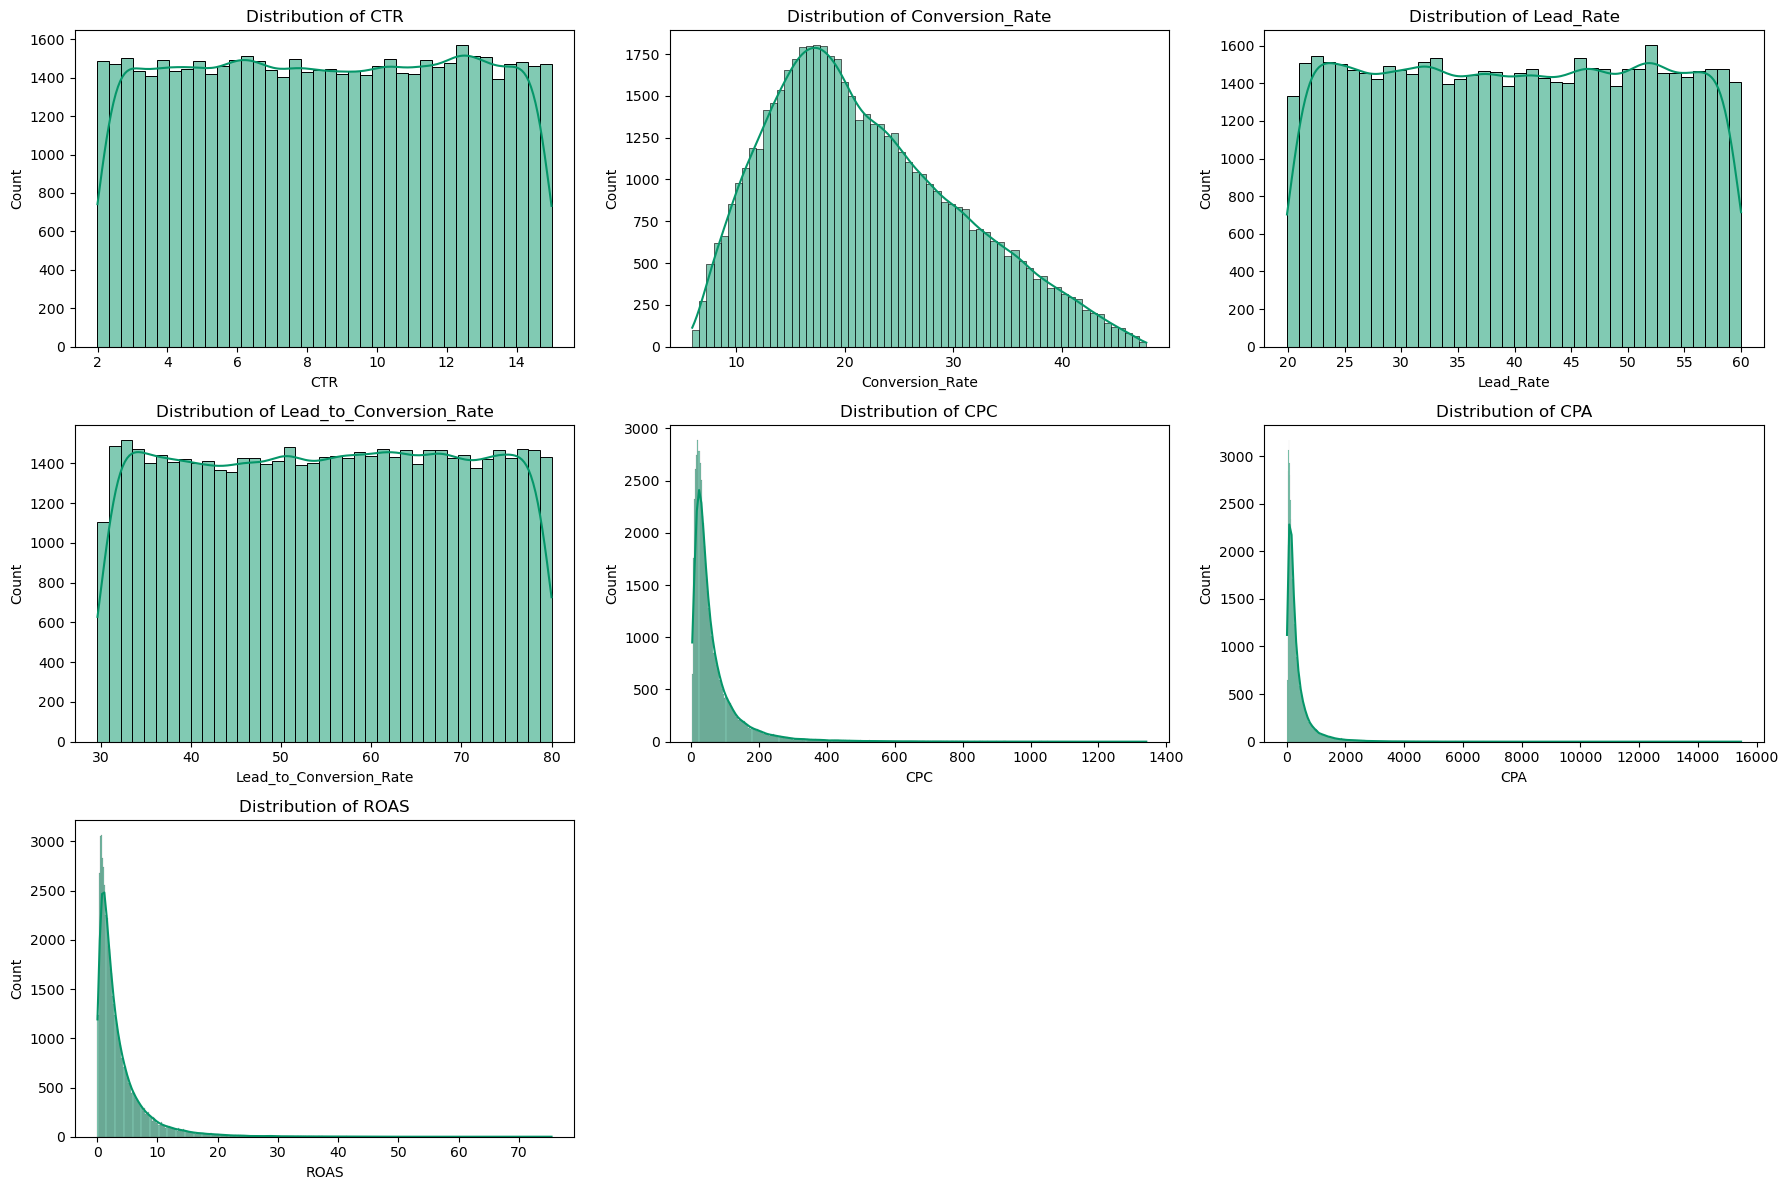

In [170]:
n = len(kpi_cols)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(kpi_cols):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[i],
        color="#059669"
    )
    axes[i].set_title(f"Distribution of {col}")

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##  Campaign Performance Analysis 

In [173]:
# Campaign Performance Analysis

campaign_perf = (
    df.groupby("Campaign_Type")
      .agg({
          "Revenue": "mean",
          "Conversions": "mean",
          "ROAS": "mean",
          "Engagement_Score": "mean"
      })
      .sort_values("Revenue", ascending=False)
)

print("Average Campaign Performance by Campaign Type")
display(campaign_perf)

Average Campaign Performance by Campaign Type


,Revenue,Conversions,ROAS,Engagement_Score
Campaign_Type,,,,
Influencer,518148.378301,1038.613167,3.699687,13.861539
Social Media,517530.827785,1043.339482,3.754760,13.845957
Paid Ads,517404.550468,1027.849316,3.722220,13.751833
SEO,514381.428559,1026.264916,3.709617,13.713328
Email,511623.631030,1028.236681,3.682708,13.747823


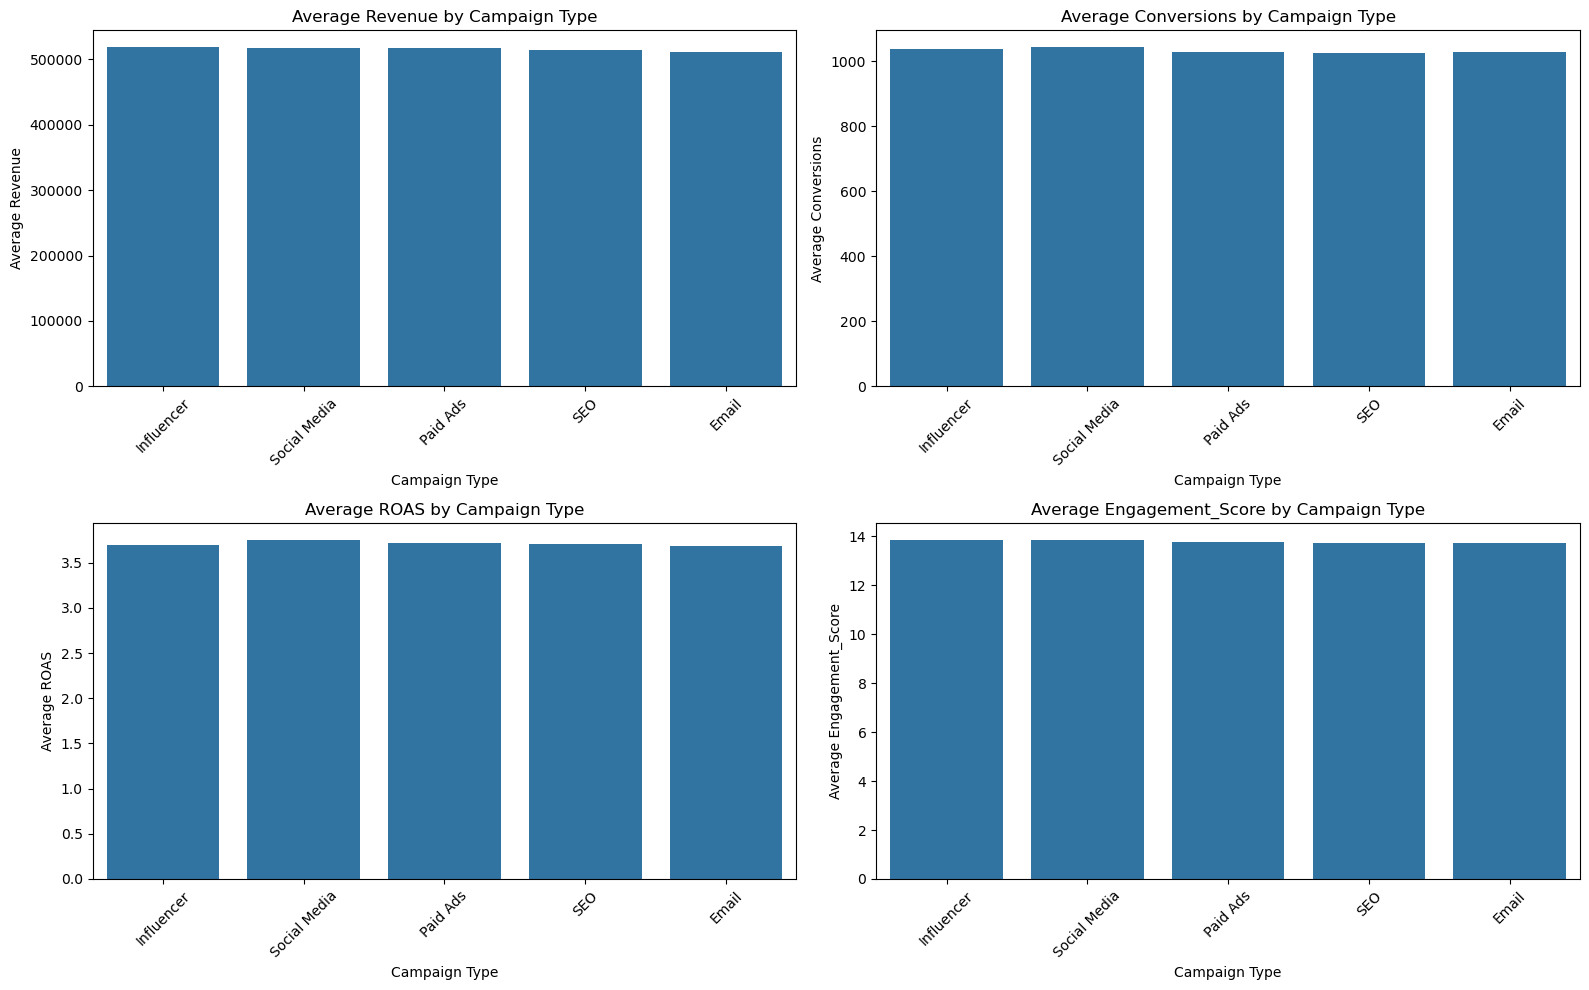

In [175]:
metrics = [
    "Revenue",
    "Conversions",
    "ROAS",
    "Engagement_Score"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

axes = axes.flatten()

for ax, col in zip(axes, metrics):
    sns.barplot(
        data=campaign_perf.reset_index(),
        x="Campaign_Type",
        y=col,
        ax=ax
    )
    
    ax.set_title(f"Average {col} by Campaign Type")
    ax.set_xlabel("Campaign Type")
    ax.set_ylabel(f"Average {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Channel Performance Analysis — by `Channel_Used`

In [177]:
# Channel Performance Analysis

channel_perf = (
    df.groupby("Channel_Used")
      .agg({
          "Revenue": "mean",
          "Conversions": "mean",
          "CTR": "mean",
          "ROAS": "mean"
      })
      .sort_values("Revenue", ascending=False)
)

print("Average Channel Performance")
display(channel_perf)

Average Channel Performance


,Revenue,Conversions,CTR,ROAS
Channel_Used,,,,
"Email, WhatsApp, Facebook",641141.413793,1203.944828,8.921475,5.230664
"YouTube, Google, Email",619047.047297,1175.986486,8.823095,4.960262
"Google, WhatsApp, YouTube",599428.671756,1127.206107,8.723168,3.919320
"Instagram, Google, WhatsApp",597656.088608,1190.063291,8.796353,4.120479
"Facebook, YouTube, Email",596210.843972,1176.482270,9.399167,4.392238
...,...,...,...,...
"YouTube, WhatsApp, Google",439849.859756,883.432927,7.715866,3.006828
"WhatsApp, YouTube, Facebook",439365.189024,887.530488,8.039116,3.464345
"WhatsApp, Email, YouTube",435218.846667,827.220000,8.016245,2.811837


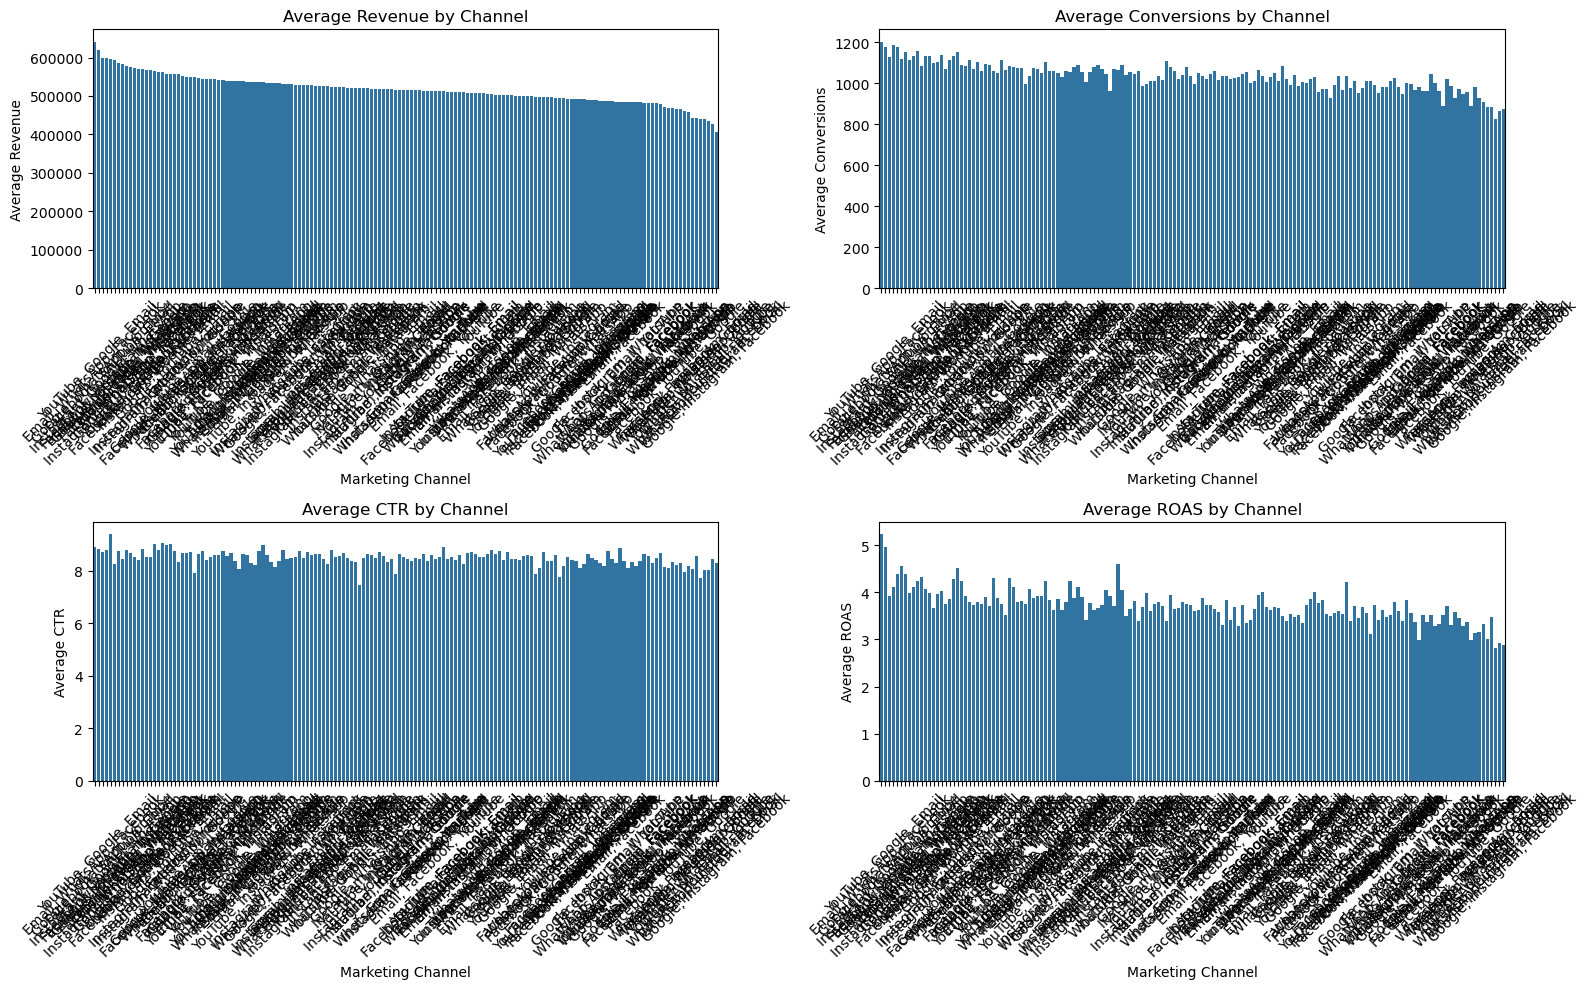

In [179]:
metrics = [
    "Revenue",
    "Conversions",
    "CTR",
    "ROAS"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

axes = axes.flatten()

for ax, col in zip(axes, metrics):
    sns.barplot(
        data=channel_perf.reset_index(),
        x="Channel_Used",
        y=col,
        ax=ax
    )
    
    ax.set_title(f"Average {col} by Channel")
    ax.set_xlabel("Marketing Channel")
    ax.set_ylabel(f"Average {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 8. Customer Segment Analysis — by `Customer_Segment`

In [181]:
# Customer Segment Performance Analysis

segment_perf = (
    df.groupby("Customer_Segment")
      .agg({
          "Revenue": "mean",
          "Conversions": "mean",
          "Engagement_Score": "mean",
          "CTR": "mean"
      })
      .sort_values("Revenue", ascending=False)
)

print("Average Performance by Customer Segment")
display(segment_perf)

Average Performance by Customer Segment


,Revenue,Conversions,Engagement_Score,CTR
Customer_Segment,,,,
Working Women,522514.341005,1046.372651,13.873177,8.568714
Tier 2 City Customers,517817.164665,1034.014738,13.833467,8.538273
Premium Shoppers,516313.444163,1034.948368,13.733730,8.471344
College Students,513548.453910,1025.736474,13.754202,8.476450
Youth,508944.617965,1023.366973,13.726836,8.489233


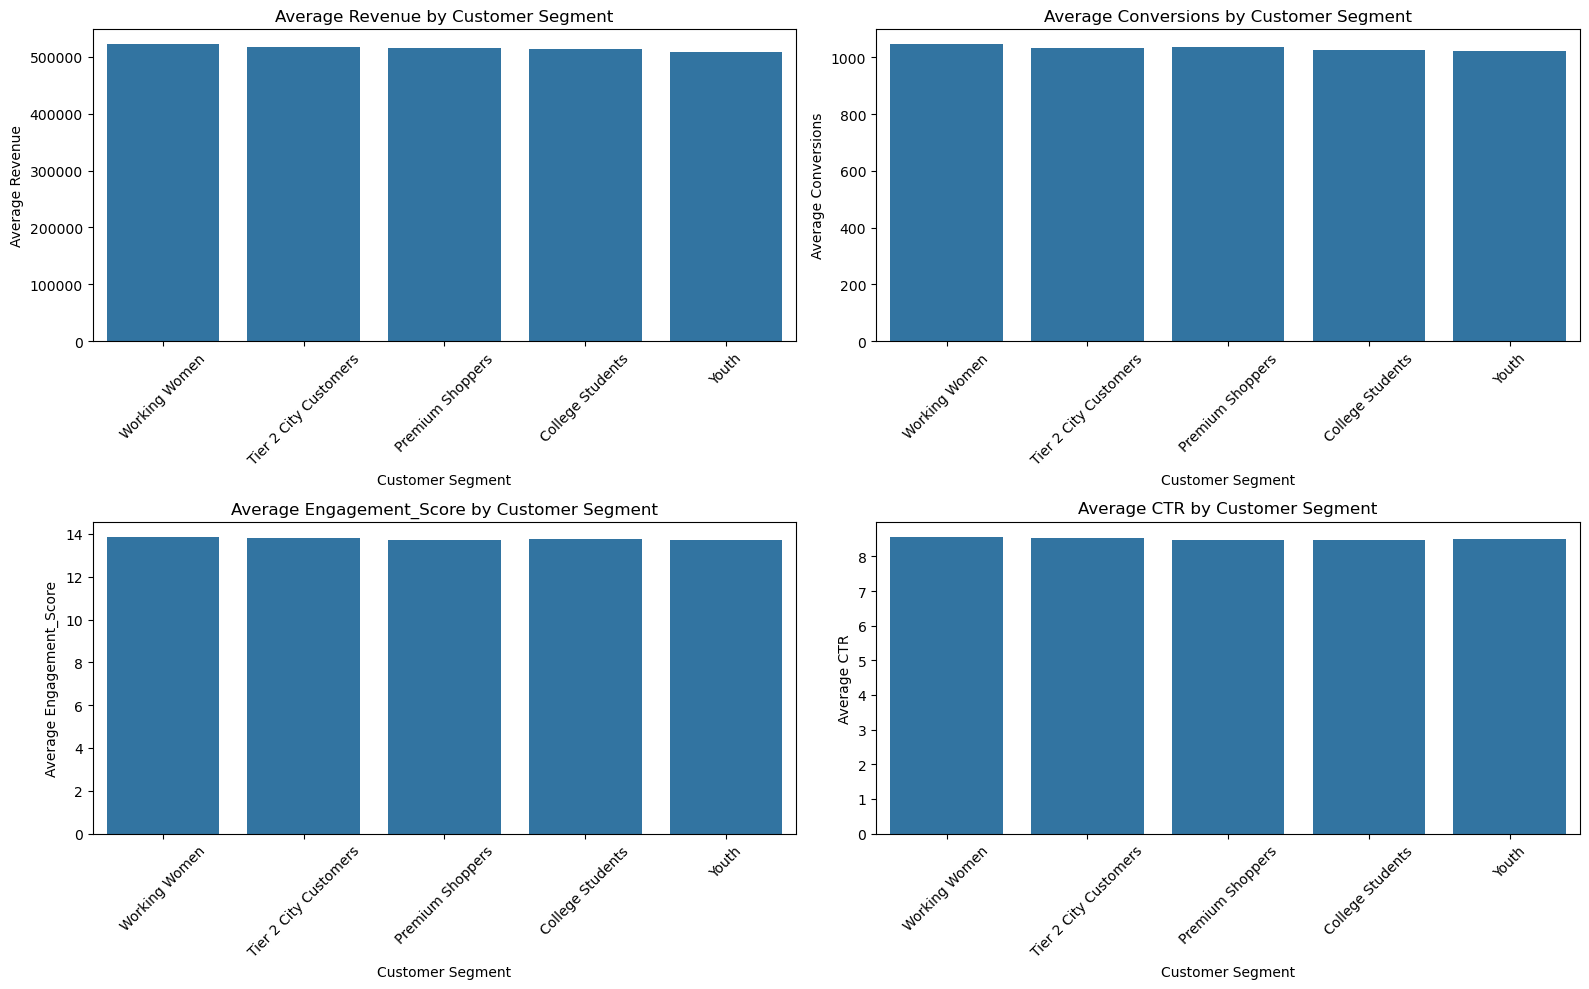

In [183]:
metrics = [
    "Revenue",
    "Conversions",
    "Engagement_Score",
    "CTR"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

axes = axes.flatten()

for ax, col in zip(axes, metrics):
    sns.barplot(
        data=segment_perf.reset_index(),
        x="Customer_Segment",
        y=col,
        ax=ax
    )
    
    ax.set_title(f"Average {col} by Customer Segment")
    ax.set_xlabel("Customer Segment")
    ax.set_ylabel(f"Average {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 9. Target Audience Analysis — by `Target_Audience`

In [185]:
# Target Audience Performance Analysis

audience_perf = (
    df.groupby("Target_Audience")
      .agg({
          "Revenue": "mean",
          "Conversions": "mean",
          "Engagement_Score": "mean",
          "CTR": "mean"
      })
      .sort_values("Revenue", ascending=False)
)

print("Average Performance by Target Audience")
display(audience_perf)

Average Performance by Target Audience


,Revenue,Conversions,Engagement_Score,CTR
Target_Audience,,,,
Premium Shoppers,523366.566357,1046.618583,13.828464,8.527100
College Students,522318.772793,1045.231450,13.852489,8.547149
Tier 2 City Customers,513609.355045,1028.765405,13.757749,8.495492
Working Women,511734.651550,1024.075374,13.808182,8.539345
Youth,507980.895269,1019.509707,13.672199,8.433082


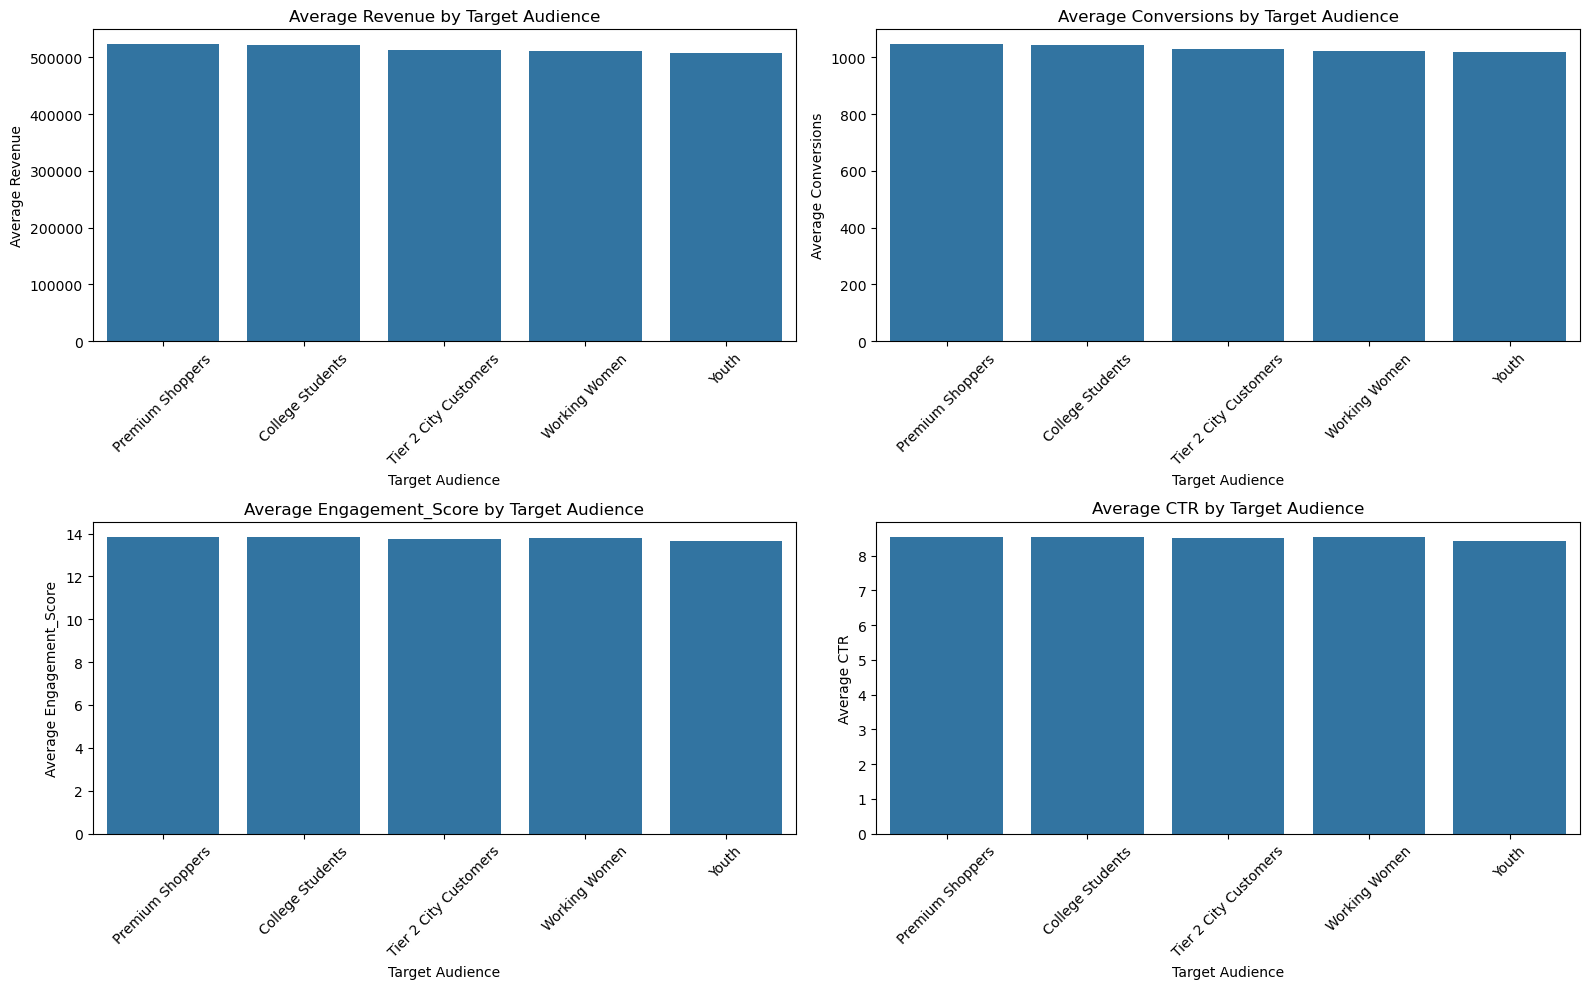

In [187]:
metrics = [
    "Revenue",
    "Conversions",
    "Engagement_Score",
    "CTR"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

axes = axes.flatten()

for ax, col in zip(axes, metrics):
    sns.barplot(
        data=audience_perf.reset_index(),
        x="Target_Audience",
        y=col,
        ax=ax
    )
    
    ax.set_title(f"Average {col} by Target Audience")
    ax.set_xlabel("Target Audience")
    ax.set_ylabel(f"Average {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Marketing Funnel Analysis


In [190]:
# Marketing Funnel Analysis

funnel_df = pd.DataFrame({
    "Stage": [
        "Impressions",
        "Clicks",
        "Leads",
        "Conversions"
    ],
    "Total": [
        df["Impressions"].sum(),
        df["Clicks"].sum(),
        df["Leads"].sum(),
        df["Conversions"].sum()
    ]
})

# Percentage retained from the previous stage
funnel_df["Rate_vs_Previous_%"] = (
    funnel_df["Total"]
    .div(funnel_df["Total"].shift(1))
    .mul(100)
)

funnel_df.loc[0, "Rate_vs_Previous_%"] = 100.0

# Percentage retained from the initial impressions stage
funnel_df["Rate_vs_Top_%"] = (
    funnel_df["Total"] / funnel_df["Total"].iloc[0] * 100
)

display(funnel_df)

,Stage,Total,Rate_vs_Previous_%,Rate_vs_Top_%
0,Impressions,3060407471,100.000000,100.000000
1,Clicks,260445757,8.510166,8.510166
2,Leads,104291797,40.043577,3.407775
3,Conversions,57380922,55.019593,1.874944


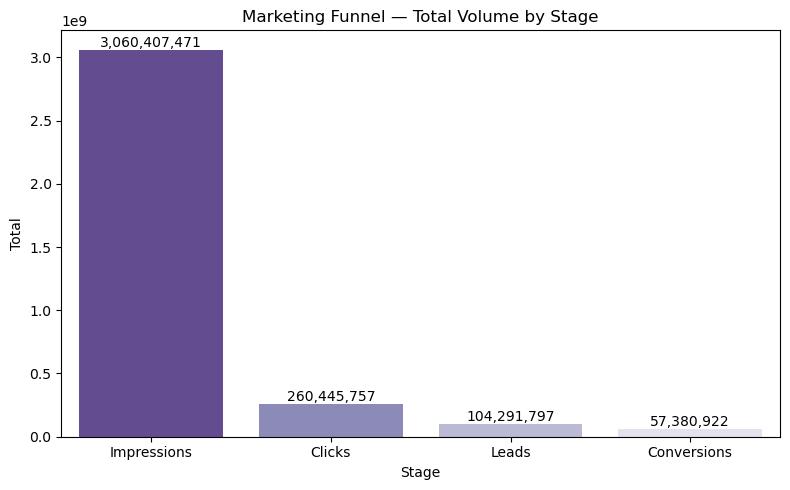

Stage-to-stage drop-off:
  Impressions -> Clicks: 8.51% retained, 91.49% drop-off
  Clicks -> Leads: 40.04% retained, 59.96% drop-off
  Leads -> Conversions: 55.02% retained, 44.98% drop-off


In [194]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Stage', y='Total', data=funnel_df, palette='Purples_r', ax=ax)
ax.set_title('Marketing Funnel — Total Volume by Stage')
for i, v in enumerate(funnel_df['Total']):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("Stage-to-stage drop-off:")
for i in range(1, len(funnel_df)):
    prev = funnel_df.iloc[i-1]
    curr = funnel_df.iloc[i]
    drop = 100 - (curr['Total'] / prev['Total'] * 100)
    print(f"  {prev['Stage']} -> {curr['Stage']}: {100 - drop:.2f}% retained, {drop:.2f}% drop-off")


## 11. Relationship Analysis

Scatter plots for key metric pairs: Impressions vs Clicks, Clicks vs Conversions,
Engagement vs Conversions, Cost vs Revenue, Cost vs Conversions.

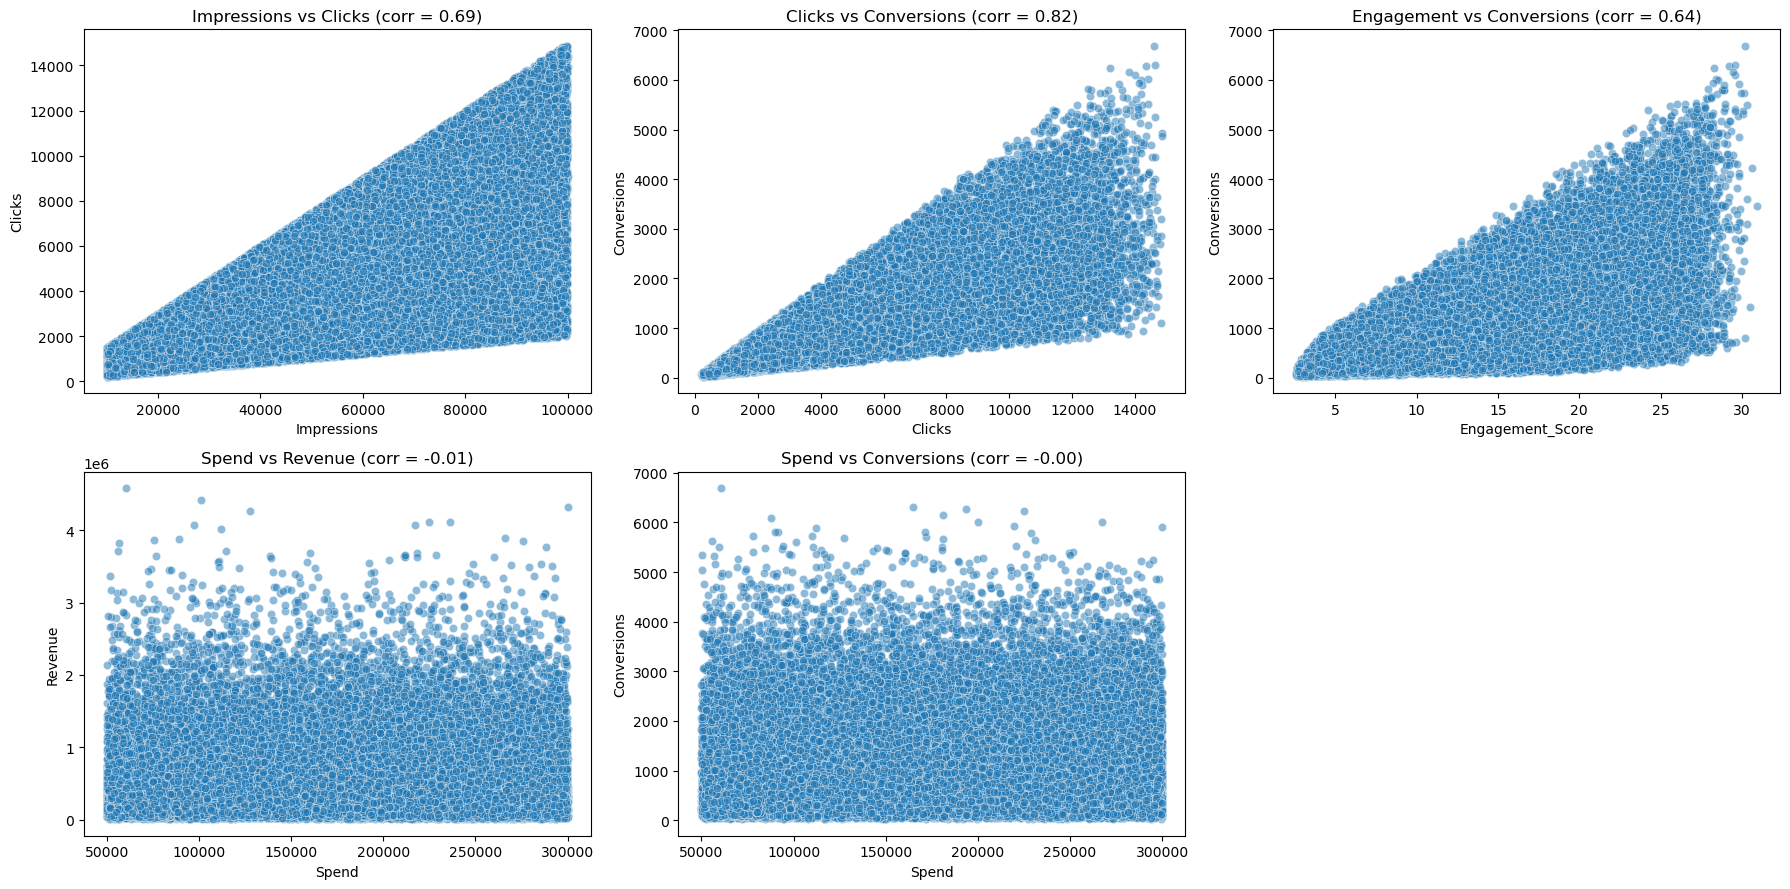

In [198]:
# Relationship Analysis

pairs = [
    ("Impressions", "Clicks", "Impressions vs Clicks"),
    ("Clicks", "Conversions", "Clicks vs Conversions"),
    ("Engagement_Score", "Conversions", "Engagement vs Conversions"),
    ("Spend", "Revenue", "Spend vs Revenue"),
    ("Spend", "Conversions", "Spend vs Conversions")
]

n = len(pairs)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows)
)

axes = np.array(axes).flatten()

for i, (x, y, title) in enumerate(pairs):

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        ax=axes[i],
        alpha=0.5
    )

    corr = df[x].corr(df[y])

    axes[i].set_title(
        f"{title} (corr = {corr:.2f})"
    )

    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 12. Correlation Analysis

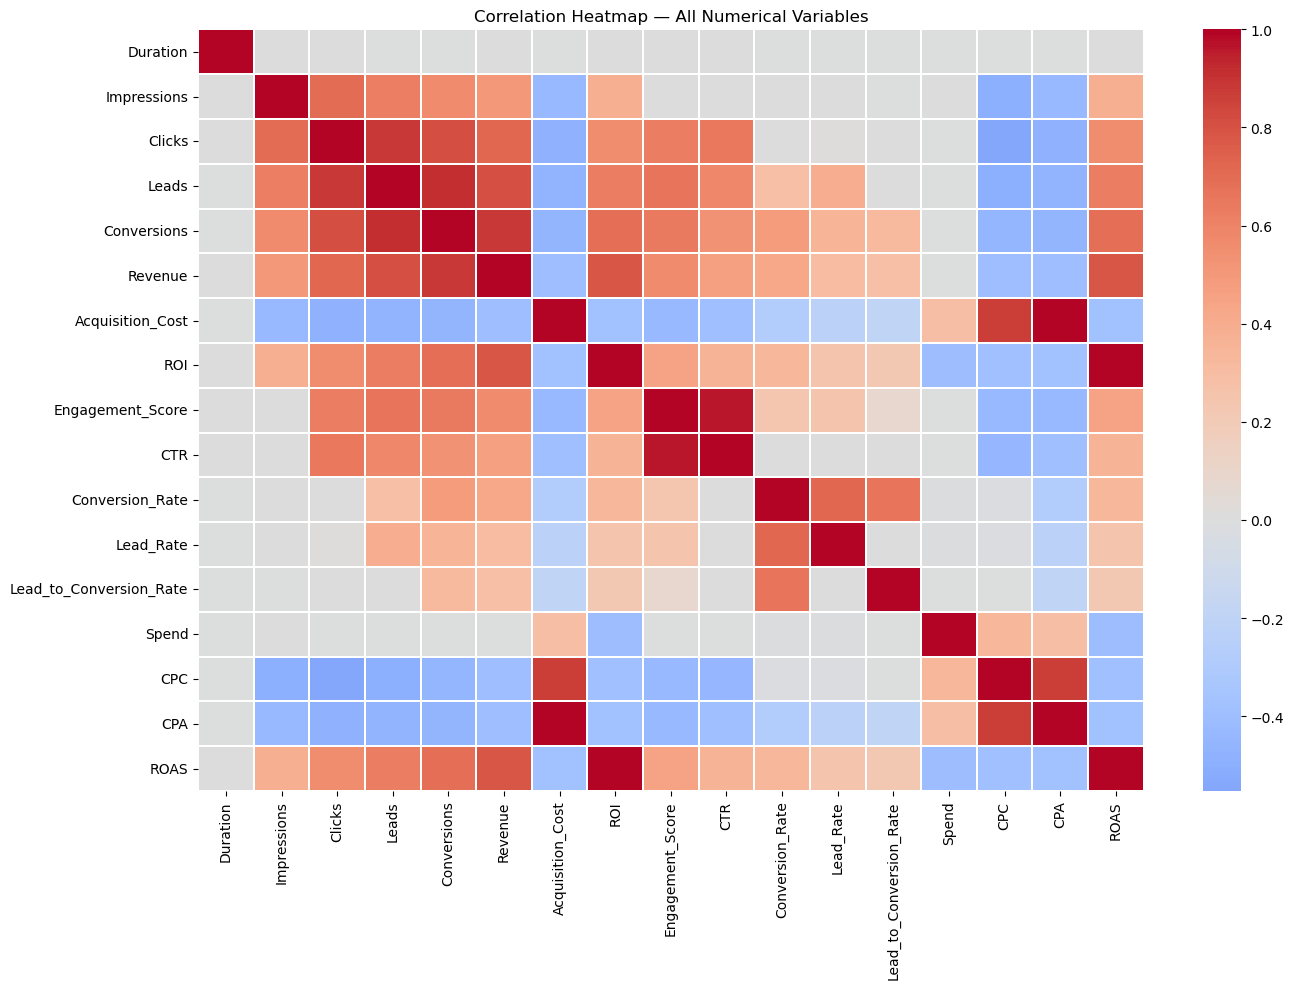

In [200]:
# Correlation Analysis

numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap — All Numerical Variables")
plt.tight_layout()
plt.show()

In [202]:
# Top correlated pairs (excluding self-correlation), for quick reference
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) \
                         .stack() \
                         .sort_values(key=lambda s: s.abs(), ascending=False)

print("Top 15 strongest correlations:")
corr_pairs.head(15)


Top 15 strongest correlations:


Acquisition_Cost  CPA            1.000000
ROI               ROAS           1.000000
Engagement_Score  CTR            0.960820
Leads             Conversions    0.917186
Clicks            Leads          0.889649
Conversions       Revenue        0.879026
CPC               CPA            0.870661
Acquisition_Cost  CPC            0.870661
Clicks            Conversions    0.815915
Leads             Revenue        0.805235
Revenue           ROAS           0.785720
                  ROI            0.785720
Conversion_Rate   Lead_Rate      0.726045
Clicks            Revenue        0.715967
Impressions       Clicks         0.693781
dtype: float64

### Budget vs Revenue

The selected dataset does not contain a dedicated Budget variable. Therefore, a direct Budget vs Revenue analysis could not be performed without introducing an unsupported assumption. Actual Spend was analyzed separately against Revenue and Conversions.

# EDA Findings

### Key Findings

1. Campaign performance varies across campaign types, with differences observed in average revenue, conversions, ROAS, and engagement.

2. Marketing channels show differences in revenue generation, conversion volume, CTR, and ROAS.

3. The dataset does not contain a Budget variable, so Budget vs Revenue could not be directly evaluated.

4. Spend and conversions show a measurable relationship, indicating an association between campaign expenditure and conversion volume.

5. CTR provides insight into how effectively campaigns convert impressions into clicks.

6. CPC varies across campaigns, indicating differences in the cost required to generate clicks.

7. Conversion Rate varies across campaigns, showing differences in the ability to convert clicks into conversions.

8. ROAS varies across campaigns, indicating differences in advertising efficiency.

9. Correlation analysis reveals relationships among the major numerical marketing variables, which can help guide subsequent feature engineering and model development.

10. Several numerical variables are right-skewed, particularly Acquisition Cost, ROI, and Revenue. Extreme observations were retained because they may represent legitimate campaign behavior.